# Memory consumption and sort performance tuning

These benchmarks were generated from a test case and
run on a machine with 16 GiB RAM and SSD storage.

The final run, with 3m lines per temp file and a 4.2 GiB
input file caused an out-of-memory exception and did not
result in a measurement.

In [1]:
results = '''file	size	n_rows	time (ms)
FL20190410_65_3-3.dia.features.100k.txt	29609129	75000	4485.037556
FL20190410_65_3-3.dia.features.100k.txt	29609129	75000	2016.183623
FL20190410_65_3-3.dia.features.100k.txt	29609129	75000	2066.949769
FL20190410_65_3-3.dia.features.100k.txt	29609129	75000	2574.736297
FL20190410_65_3-3.dia.features.100k.txt	29609129	75000	1965.687964
FL20190410_65_3-3.dia.features.100k.txt	29609129	100000	1196.587773
FL20190410_65_3-3.dia.features.100k.txt	29609129	100000	1260.254001
FL20190410_65_3-3.dia.features.100k.txt	29609129	100000	1218.421273
FL20190410_65_3-3.dia.features.100k.txt	29609129	100000	1450.728608
FL20190410_65_3-3.dia.features.100k.txt	29609129	100000	1417.07791
FL20190410_65_3-3.dia.features.100k.txt	29609129	150000	1731.644324
FL20190410_65_3-3.dia.features.100k.txt	29609129	150000	1423.336511
FL20190410_65_3-3.dia.features.100k.txt	29609129	150000	1389.325072
FL20190410_65_3-3.dia.features.100k.txt	29609129	150000	1903.721265
FL20190410_65_3-3.dia.features.100k.txt	29609129	150000	1384.96553
FL20190410_65_3-3.dia.features.100k.txt	29609129	225000	1593.337322
FL20190410_65_3-3.dia.features.100k.txt	29609129	225000	1377.604556
FL20190410_65_3-3.dia.features.100k.txt	29609129	225000	1210.71686
FL20190410_65_3-3.dia.features.100k.txt	29609129	225000	1671.998589
FL20190410_65_3-3.dia.features.100k.txt	29609129	225000	1220.171487
FL20190410_65_3-3.dia.features.100k.txt	29609129	350000	1208.493914
FL20190410_65_3-3.dia.features.100k.txt	29609129	350000	1329.212941
FL20190410_65_3-3.dia.features.100k.txt	29609129	350000	1215.673057
FL20190410_65_3-3.dia.features.100k.txt	29609129	350000	1729.063081
FL20190410_65_3-3.dia.features.100k.txt	29609129	350000	1374.247708
FL20190410_65_3-3.dia.features.100k.txt	29609129	500000	1693.648357
FL20190410_65_3-3.dia.features.100k.txt	29609129	500000	1353.252548
FL20190410_65_3-3.dia.features.100k.txt	29609129	500000	1424.202512
FL20190410_65_3-3.dia.features.100k.txt	29609129	500000	1561.040196
FL20190410_65_3-3.dia.features.100k.txt	29609129	500000	1271.112794
FL20190410_65_3-3.dia.features.500k.txt	148264117	75000	10429.129414
FL20190410_65_3-3.dia.features.500k.txt	148264117	75000	10004.505694
FL20190410_65_3-3.dia.features.500k.txt	148264117	75000	9887.232493
FL20190410_65_3-3.dia.features.500k.txt	148264117	75000	9651.093069
FL20190410_65_3-3.dia.features.500k.txt	148264117	75000	9516.975396
FL20190410_65_3-3.dia.features.500k.txt	148264117	100000	10961.482858
FL20190410_65_3-3.dia.features.500k.txt	148264117	100000	9904.114813
FL20190410_65_3-3.dia.features.500k.txt	148264117	100000	11485.892437
FL20190410_65_3-3.dia.features.500k.txt	148264117	100000	10423.24379
FL20190410_65_3-3.dia.features.500k.txt	148264117	100000	10409.812774
FL20190410_65_3-3.dia.features.500k.txt	148264117	150000	10945.687814
FL20190410_65_3-3.dia.features.500k.txt	148264117	150000	9864.840269
FL20190410_65_3-3.dia.features.500k.txt	148264117	150000	11725.397643
FL20190410_65_3-3.dia.features.500k.txt	148264117	150000	10671.259301
FL20190410_65_3-3.dia.features.500k.txt	148264117	150000	10889.285615
FL20190410_65_3-3.dia.features.500k.txt	148264117	225000	10200.77724
FL20190410_65_3-3.dia.features.500k.txt	148264117	225000	10026.491584
FL20190410_65_3-3.dia.features.500k.txt	148264117	225000	12449.761916
FL20190410_65_3-3.dia.features.500k.txt	148264117	225000	10710.628255
FL20190410_65_3-3.dia.features.500k.txt	148264117	225000	12638.365357
FL20190410_65_3-3.dia.features.500k.txt	148264117	350000	10369.160084
FL20190410_65_3-3.dia.features.500k.txt	148264117	350000	11205.984959
FL20190410_65_3-3.dia.features.500k.txt	148264117	350000	11654.649872
FL20190410_65_3-3.dia.features.500k.txt	148264117	350000	11025.057524
FL20190410_65_3-3.dia.features.500k.txt	148264117	350000	10279.971127
FL20190410_65_3-3.dia.features.500k.txt	148264117	500000	7547.116622
FL20190410_65_3-3.dia.features.500k.txt	148264117	500000	7303.108789
FL20190410_65_3-3.dia.features.500k.txt	148264117	500000	7470.56119
FL20190410_65_3-3.dia.features.500k.txt	148264117	500000	7497.588293
FL20190410_65_3-3.dia.features.500k.txt	148264117	500000	6015.624919
FL20190410_65_3-3.dia.features.1000k.txt	297582766	75000	19430.045469
FL20190410_65_3-3.dia.features.1000k.txt	297582766	75000	17874.772546
FL20190410_65_3-3.dia.features.1000k.txt	297582766	75000	17972.330837
FL20190410_65_3-3.dia.features.1000k.txt	297582766	75000	17802.816664
FL20190410_65_3-3.dia.features.1000k.txt	297582766	75000	17772.322741
FL20190410_65_3-3.dia.features.1000k.txt	297582766	100000	18213.197469
FL20190410_65_3-3.dia.features.1000k.txt	297582766	100000	19009.59113
FL20190410_65_3-3.dia.features.1000k.txt	297582766	100000	17672.249173
FL20190410_65_3-3.dia.features.1000k.txt	297582766	100000	18993.039144
FL20190410_65_3-3.dia.features.1000k.txt	297582766	100000	18142.831686
FL20190410_65_3-3.dia.features.1000k.txt	297582766	150000	19718.76211
FL20190410_65_3-3.dia.features.1000k.txt	297582766	150000	20185.243585
FL20190410_65_3-3.dia.features.1000k.txt	297582766	150000	20414.571934
FL20190410_65_3-3.dia.features.1000k.txt	297582766	150000	21278.490183
FL20190410_65_3-3.dia.features.1000k.txt	297582766	150000	19386.486119
FL20190410_65_3-3.dia.features.1000k.txt	297582766	225000	22411.470186
FL20190410_65_3-3.dia.features.1000k.txt	297582766	225000	22977.446577
FL20190410_65_3-3.dia.features.1000k.txt	297582766	225000	22848.0907
FL20190410_65_3-3.dia.features.1000k.txt	297582766	225000	21889.253239
FL20190410_65_3-3.dia.features.1000k.txt	297582766	225000	20771.000285
FL20190410_65_3-3.dia.features.1000k.txt	297582766	350000	23126.263025
FL20190410_65_3-3.dia.features.1000k.txt	297582766	350000	23551.180951
FL20190410_65_3-3.dia.features.1000k.txt	297582766	350000	22321.607174
FL20190410_65_3-3.dia.features.1000k.txt	297582766	350000	23719.403969
FL20190410_65_3-3.dia.features.1000k.txt	297582766	350000	22755.167925
FL20190410_65_3-3.dia.features.1000k.txt	297582766	500000	21963.909052
FL20190410_65_3-3.dia.features.1000k.txt	297582766	500000	23290.519836
FL20190410_65_3-3.dia.features.1000k.txt	297582766	500000	22453.781124
FL20190410_65_3-3.dia.features.1000k.txt	297582766	500000	22873.467707
FL20190410_65_3-3.dia.features.1000k.txt	297582766	500000	23630.56384
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	75000	90677.327553
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	75000	84031.372874
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	75000	83566.651496
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	75000	92832.057014
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	75000	84704.908936
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	100000	91745.173203
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	100000	95077.813166
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	100000	89637.293421
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	100000	91706.290672
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	100000	90654.14241
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	150000	95672.061899
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	150000	89182.694262
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	150000	89705.132201
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	150000	92737.407625
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	150000	90829.501056
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	225000	94241.196172
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	225000	99920.805156
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	225000	99435.921545
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	225000	92480.304894
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	225000	95771.234794
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	350000	93615.964998
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	350000	100188.749764
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	350000	98140.627376
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	350000	110202.225997
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	350000	111265.29542
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	500000	115533.731058
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	500000	105849.658929
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	500000	109004.082549
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	500000	112345.186502
FL20190410_65_3-3.dia.features.4187k.txt	1293596070	500000	113027.218766'''

In [2]:
import pandas as pd
from io import StringIO

In [3]:
df = pd.read_csv(StringIO(results), sep='\t')

In [4]:
gb = df.drop('file', axis=1).groupby(['size', 'n_rows'])

In [5]:
meds = gb.median().unstack()

In [6]:
meds

time (ms)                                            \
n_rows            75000         100000        150000        225000   
size                                                                 
29609129     2066.949769   1260.254001   1423.336511   1377.604556   
148264117    9887.232493  10423.243790  10889.285615  10710.628255   
297582766   17874.772546  18213.197469  20185.243585  22411.470186   
1293596070  84704.908936  91706.290672  90829.501056  95771.234794   

                                          
n_rows             350000         500000  
size                                      
29609129      1329.212941    1424.202512  
148264117    11025.057524    7470.561190  
297582766    23126.263025   22873.467707  
1293596070  100188.749764  112345.186502

In [7]:
iqrs = gb.quantile(0.75)-gb.quantile(0.25)

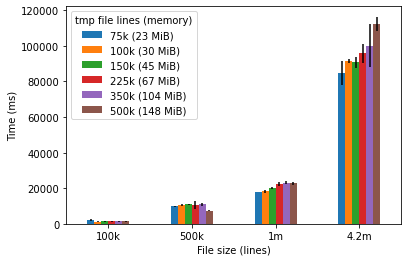

In [8]:
ax = meds.plot.bar(yerr=iqrs.unstack(), rot=0)

ax.set_xlabel('File size (lines)')
ax.set_xticklabels(['100k', '500k', '1m', '4.2m'])

ax.set_ylabel('Time (ms)')

ax.legend(
    [
        '75k (23 MiB)',
        '100k (30 MiB)',
        '150k (45 MiB)',
        '225k (67 MiB)',
        '350k (104 MiB)',
        '500k (148 MiB)'
    ],
    title='tmp file lines (memory)'
)